Citations: Andrew Lucas: Ising formulations of many NP Problems. arXiv:1302.5843. 
https://arxiv.org/abs/1302.5843

Ising machine: Set Packing / Maximum Independent Set (MIS)

Given an undirected graph G = (V, E), the Maximum Independent Set problem asks:
what is the largest set of vertices such that no two vertices in the set are
connected by an edge? This is isomorphic to the Set Packing problem (Lucas
§4.2), which similarly asks what is the largest number of subsets V(i) (see
Exact Cover) which are all disjoint. This problem is NP-hard

The Hamiltonian is H = H_A + H_B where:
- H_A = A * sum_{(ij) in E} x_i * x_j  (penalises selecting adjacent vertices)
- H_B = -B * sum_i x_i                  (rewards selecting more vertices)

Choose B < A so that violating the independence constraint is never favourable.

Note that since this problem is NP-hard, minimum energy will be <0.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from helpers.helpers import generate_adjacency_matrix_undirected, init_random_spins

In [2]:
# ---- Energy Functions ----

def get_ha(adjacency_matrix, xalpha, A):
    """Penalty for selecting two adjacent vertices."""
    N = len(xalpha)
    ha = 0
    for i in range(N):
        for j in range(i + 1, N):
            if adjacency_matrix[i, j] == 1:
                ha += xalpha[i] * xalpha[j]
    return A * ha

def get_hb(xalpha, B):
    """Reward for selecting more vertices."""
    return -B * np.sum(xalpha)

def calc_energy(adjacency_matrix, xalpha, A, B):
    return get_ha(adjacency_matrix, xalpha, A) + get_hb(xalpha, B)

In [3]:
# ---- Metropolis / Simulated Annealing ----

def metropolis(adjacency_matrix, xalpha, A, B, T_start, steps):
    N = len(xalpha)
    xalpha = xalpha.copy()
    energy = calc_energy(adjacency_matrix, xalpha, A, B)
    best_xalpha = xalpha.copy()
    best_energy = energy

    for step in range(steps):
        j = np.random.randint(0, N)
        xalpha[j] = 1 - xalpha[j]
        new_energy = calc_energy(adjacency_matrix, xalpha, A, B)
        delta_energy = new_energy - energy

        T = T_start / (1 + step * 0.001)
        if delta_energy < 0 or np.random.rand() < np.exp(-delta_energy / T):
            energy = new_energy
            if energy < best_energy:
                best_energy = energy
                best_xalpha = xalpha.copy()
        else:
            xalpha[j] = 1 - xalpha[j]

    return best_xalpha, best_energy

In [4]:
# ---- Plotting ----

def plot_independent_set(adjacency_matrix, xalpha):
    N = adjacency_matrix.shape[0]
    G = nx.from_numpy_array(adjacency_matrix)
    pos = nx.spring_layout(G, seed=42)

    colours = ['red' if xalpha[i] == 1 else 'lightblue' for i in range(N)]

    plt.figure(figsize=(6, 6))
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=1)
    nx.draw_networkx_nodes(G, pos, node_color=colours, node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=12)

    selected = [i for i in range(N) if xalpha[i] == 1]
    plt.title(f"Maximum Independent Set (size {len(selected)}): {selected}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Initial configuration: [1 1 1 0 1 1 1 0 0 1]
Initial energy: 3.0

Maximum Independent Set found: [0, 2, 3, 5, 6, 7]
Size: 6
Final energy: -6.0
H_A (should be 0): 0.0


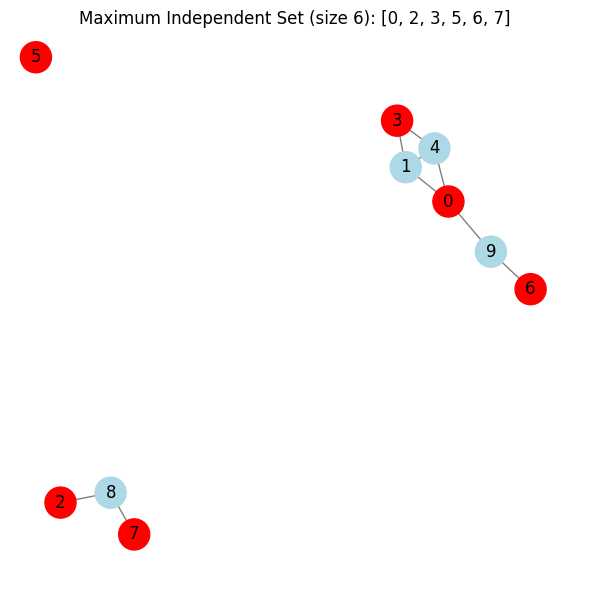

In [ ]:
# ---- Run ----

N = 10
adj_p = 0.3
A = 2.0   # penalty weight for adjacent vertices
B = 1.0   # reward weight (B < A required)
T_start = 5.0
steps = 500000

adjacency_matrix = generate_adjacency_matrix_undirected(N, adj_p)
xalpha = np.random.randint(2, size=N).flatten()

print("Initial configuration:", xalpha)
print("Initial energy:", calc_energy(adjacency_matrix, xalpha, A, B))

best_xalpha, best_energy = metropolis(adjacency_matrix, xalpha, A, B, T_start, steps)

selected = [i for i in range(N) if best_xalpha[i] == 1]
print(f"\nMaximum Independent Set found: {selected}")
print(f"Size: {len(selected)}")
print(f"Final energy: {best_energy}")
print(f"H_A (should be 0): {get_ha(adjacency_matrix, best_xalpha, A)}")

plot_independent_set(adjacency_matrix, best_xalpha)

In [6]:
# ---- Verify: no two selected vertices are adjacent ----

def verify_independent_set(adjacency_matrix, xalpha):
    selected = [i for i in range(len(xalpha)) if xalpha[i] == 1]
    for i in range(len(selected)):
        for j in range(i + 1, len(selected)):
            if adjacency_matrix[selected[i], selected[j]] == 1:
                print(f"INVALID: vertices {selected[i]} and {selected[j]} are adjacent")
                return False
    print(f"VALID independent set of size {len(selected)}")
    return True

verify_independent_set(adjacency_matrix, best_xalpha)

VALID independent set of size 6


True